Notebook 9: Dataset 3 Independent Test + Grad-CAM
============================================================
Sequential Transfer Learning for Medicinal Plant Identification
Student: Hari (3146279) | BSc Software Engineering | University of Stirling

This notebook:
1. Evaluates the best model on Dataset 3 (completely held-out test set)
2. Generates Grad-CAM visualisations for selected species
3. Produces confusion matrix and per-species metrics

This tests generalisation — we need to verify
performance on data the model has NEVER seen during training.

Run in Google Colab with GPU runtime!
Runtime -> Change runtime type -> GPU

## Mount Drive and Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import json
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)
import seaborn as sns

print(f"TensorFlow: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f"GPU: {gpus[0].name}")
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

Mounted at /content/drive
TensorFlow: 2.19.0


## Configuration

In [2]:
IMG_SIZE = (224, 224)  # Must match training pipeline
BATCH_SIZE = 32
SEED = 42

DRIVE_BASE = "/content/drive/MyDrive"
PROJECT_DIR = os.path.join(DRIVE_BASE, "MedicinalPlant_Dissertation")
DATA_DIR = os.path.join(PROJECT_DIR, "data")
MODEL_DIR = os.path.join(PROJECT_DIR, "models")
RESULTS_DIR = os.path.join(PROJECT_DIR, "dataset3_results")
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"Results will be saved to: {RESULTS_DIR}")

Results will be saved to: /content/drive/MyDrive/MedicinalPlant_Dissertation/dataset3_results


## Find and Load Dataset 3 (Independent Test Set)

In [3]:
def find_image_directory(base_dir):
    """Walk directory tree to find folder containing class subdirectories with images."""
    if not os.path.exists(base_dir):
        return None
    for root, dirs, files in os.walk(base_dir):
        dirs[:] = [d for d in dirs if not d.startswith('.')]
        if not dirs:
            continue
        sample_dir = os.path.join(root, dirs[0])
        if os.path.isdir(sample_dir):
            sample_files = os.listdir(sample_dir)
            has_images = any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in sample_files)
            if has_images:
                return root
    return None

print(">>> Finding Dataset 3 (Independent Test Set)...")

dataset3_path = None
possible_paths = [
    os.path.join(DATA_DIR, "dataset3"),
    os.path.join(DATA_DIR, "Dataset 3"),
    os.path.join(DATA_DIR, "medicinal_leaf"),
]

for p in possible_paths:
    if os.path.exists(p):
        found = find_image_directory(p)
        if found:
            dataset3_path = found
            break

if dataset3_path is None:
    raise FileNotFoundError(
        "Could not find Dataset 3!\n"
        f"Expected at: {DATA_DIR}/dataset3/\n"
        "Make sure your data is in Google Drive.\n"
        "Dataset 3 = 'Medicinal Leaf Dataset' from Mendeley (~900 images, 9 species)"
    )

# List classes
d3_classes = sorted([
    d for d in os.listdir(dataset3_path)
    if os.path.isdir(os.path.join(dataset3_path, d)) and not d.startswith('.')
])
print(f"\nDataset 3 found: {dataset3_path}")
print(f"Classes ({len(d3_classes)}): {d3_classes}")

total_imgs = 0
for c in d3_classes:
    n = len([f for f in os.listdir(os.path.join(dataset3_path, c))
             if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total_imgs += n
    print(f"  {c:30s} {n:4d} images")
print(f"  {'TOTAL':30s} {total_imgs:4d} images")

>>> Finding Dataset 3 (Independent Test Set)...

Dataset 3 found: /content/drive/MyDrive/MedicinalPlant_Dissertation/data/dataset3/Medicinal Leaf Dataset/Medicinal Leaf Dataset
Classes (9): ['Allium cepa (Onion)', 'Aloe vera (syn. Aloe barbadensis) (Aloe Vera)', 'Bergera koenigii (syn. Murraya koenigii)(Curry Tree)', 'Coriandrum sativum (Coriander)', 'Mentha spp. (Mint)', 'Piper betle(Betel)', 'Raphanus sativus (Radish)', 'Senna tora (syn Cassia tora) (Tora Leaves)', 'Trigonella foenum-graecum (Fenugreek)']
  Allium cepa (Onion)             107 images
  Aloe vera (syn. Aloe barbadensis) (Aloe Vera)  103 images
  Bergera koenigii (syn. Murraya koenigii)(Curry Tree)  112 images
  Coriandrum sativum (Coriander)  107 images
  Mentha spp. (Mint)              114 images
  Piper betle(Betel)              114 images
  Raphanus sativus (Radish)       136 images
  Senna tora (syn Cassia tora) (Tora Leaves)  108 images
  Trigonella foenum-graecum (Fenugreek)  108 images
  TOTAL                   

## Load the trained model

In [4]:
print("\n>>> Loading trained model...")

import zipfile, re as _re

model = None
model_paths = [
    os.path.join(MODEL_DIR, "phase3b_commercial.keras"),
    os.path.join(MODEL_DIR, "phase3b_best.keras"),
    os.path.join(MODEL_DIR, "phase3b_model.keras"),
    os.path.join(PROJECT_DIR, "phase3b_commercial.keras"),
]

# ── Attempt 1: standard load_model ──────────────────────────────────
for mp in model_paths:
    if not os.path.exists(mp):
        continue
    print(f"  Trying: {mp}")
    for kw in [dict(compile=False), dict(compile=False, safe_mode=False)]:
        try:
            model = keras.models.load_model(mp, **kw)
            print(f"  [OK] Loaded ({kw})")
            break
        except Exception as e:
            print(f"  [FAIL] load_model failed ({kw}): {e}")
    if model is not None:
        break

# ── Attempt 2: rebuild architecture + load weights from .keras ZIP ──
#   Keras 3 / TF ≥2.16 has a BatchNormalization deserialization bug that
#   corrupts the computational graph during load_model() — the BN layer
#   receives two copies of the *wrong* tensor instead of one correct one.
#   No amount of monkey-patching can fix a broken graph.
#
#   Workaround: bypass the deserializer entirely.
#     1. Open the .keras file (it's a ZIP containing config.json + weights).
#     2. Extract model.weights.h5 (the trained parameter values).
#     3. Rebuild the exact Phase-3b architecture from scratch.
#     4. Call model.load_weights() to inject the trained parameters.
#
#   CRITICAL: the temp file MUST end in '.weights.h5' so Keras 3 uses its
#   native weight-format loader (index-based paths).  A plain '.h5' extension
#   triggers the legacy loader which expects layer-name HDF5 groups and fails
#   with "found 0 saved layers".
if model is None:
    print("\n  Attempting rebuild + weight extraction from .keras archive …")
    weights_tmp = os.path.join(RESULTS_DIR, '_temp_model.weights.h5')

    for mp in model_paths:
        if not os.path.exists(mp) or not mp.endswith('.keras'):
            continue
        try:
            # ── Step 1: extract config + weights from ZIP ──
            with zipfile.ZipFile(mp, 'r') as zf:
                archive_files = zf.namelist()
                print(f"  Archive contents: {archive_files}")
                config = json.loads(zf.read('config.json'))
                with zf.open('model.weights.h5') as src, \
                     open(weights_tmp, 'wb') as dst:
                    dst.write(src.read())

            # Determine NUM_CLASSES from last Dense layer in config
            num_classes = 20
            cfg_layers = (config.get('config', config)).get('layers', [])
            for lc in reversed(cfg_layers):
                if lc.get('class_name') == 'Dense':
                    num_classes = lc['config']['units']
                    break
            print(f"  Config → {num_classes} output classes")

            # ── Step 2: rebuild the exact Phase-3b architecture ──
            # clear_session resets name-counters so auto-names match the
            # original model's layer indices in the weight file.
            keras.backend.clear_session()
            from tensorflow.keras.applications import ResNet50

            base = ResNet50(weights=None, include_top=False,
                            input_shape=(224, 224, 3))

            aug = keras.Sequential([
                layers.RandomFlip("horizontal"),
                layers.RandomRotation(0.1),
                layers.RandomZoom(0.1),
                layers.RandomContrast(0.1),
            ], name="augmentation_commercial")

            model = keras.Sequential([
                keras.Input(shape=(224, 224, 3)),
                aug,
                base,
                layers.GlobalAveragePooling2D(),
                layers.BatchNormalization(),
                layers.Dropout(0.4),
                layers.Dense(512, activation='relu'),
                layers.BatchNormalization(),
                layers.Dropout(0.3),
                layers.Dense(256, activation='relu'),
                layers.BatchNormalization(),
                layers.Dropout(0.2),
                layers.Dense(num_classes, activation='softmax'),
            ], name="phase3b_commercial")

            # ── Step 3: load trained weights ──
            model.load_weights(weights_tmp)
            print(f"  [OK] Rebuilt architecture + loaded weights from {os.path.basename(mp)}")
            break
        except Exception as e:
            print(f"  [FAIL] Rebuild failed for {os.path.basename(mp)}: {e}")
            import traceback; traceback.print_exc()
            model = None
        finally:
            if os.path.exists(weights_tmp):
                os.remove(weights_tmp)

# ── Attempt 3: legacy .h5 files ─────────────────────────────────────
if model is None:
    h5_paths = [p.replace('.keras', '.h5') for p in model_paths]
    for mp in h5_paths:
        if not os.path.exists(mp):
            continue
        print(f"\n  Trying H5: {mp}")
        try:
            model = keras.models.load_model(mp, compile=False)
            print(f"  [OK] Loaded from H5!")
            break
        except Exception as e:
            print(f"  [FAIL] H5 failed: {e}")

if model is None:
    raise FileNotFoundError(
        "Could not load any model! Check MODEL_DIR.\n"
        "Try uploading the model file again to Google Drive."
    )

n_outputs = model.output_shape[-1]
print(f"\n  Model output classes: {n_outputs}")

# ── Load class names from training ──────────────────────────────────
class_names_path = None
for p in [
    os.path.join(MODEL_DIR, "phase3b_class_names.json"),
    os.path.join(PROJECT_DIR, "phase3b_class_names.json"),
    os.path.join(MODEL_DIR, "class_names.json"),
    os.path.join(PROJECT_DIR, "class_names.json"),
    os.path.join(MODEL_DIR, "improved_class_names.json"),
    os.path.join(PROJECT_DIR, "improved_class_names.json"),
]:
    if os.path.exists(p):
        class_names_path = p
        break

if class_names_path:
    with open(class_names_path, 'r') as f:
        train_class_names = json.load(f)
    print(f"  Loaded class names from: {os.path.basename(class_names_path)}")
    if len(train_class_names) > n_outputs:
        print(f"  NOTE: File has {len(train_class_names)} names but model has {n_outputs} outputs")
        print(f"  Trimming to first {n_outputs} (dropped species had 0-1 images)")
        train_class_names = train_class_names[:n_outputs]
    print(f"  Training classes ({len(train_class_names)}): {train_class_names}")
else:
    print("  WARNING: class_names.json not found. Using model output layer size.")
    train_class_names = [f"class_{i}" for i in range(n_outputs)]

# Print model layer summary for debugging
print(f"\n  Model layers ({len(model.layers)}):")
for i, layer in enumerate(model.layers):
    nested = f" [nested: {len(layer.layers)} sublayers]" if hasattr(layer, 'layers') else ""
    print(f"    {i}: {layer.__class__.__name__:25s} {layer.name}{nested}")


>>> Loading trained model...
  Trying: /content/drive/MyDrive/MedicinalPlant_Dissertation/models/phase3b_commercial.keras
  [FAIL] load_model failed ({'compile': False}): Layer "batch_normalization" expects 1 input(s), but it received 2 input tensors. Inputs received: [<KerasTensor shape=(None, 7, 7, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_383>, <KerasTensor shape=(None, 7, 7, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_384>]
  [FAIL] load_model failed ({'compile': False, 'safe_mode': False}): Layer "batch_normalization" expects 1 input(s), but it received 2 input tensors. Inputs received: [<KerasTensor shape=(None, 7, 7, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_768>, <KerasTensor shape=(None, 7, 7, 2048), dtype=float32, sparse=False, ragged=False, name=keras_tensor_769>]

  Attempting rebuild + weight extraction from .keras archive …
  Archive contents: ['metadata.json', 'config.json', 'model.weights.h5']


## Prepare Dataset 3 images for prediction

In [5]:
# Since Dataset 3 may have different species names than the training set,
# we need to handle the mapping carefully.
print("\n>>> Preparing Dataset 3 for evaluation...")

# Load all images from Dataset 3
all_images = []
all_true_labels = []
all_filenames = []

for species_name in d3_classes:
    species_dir = os.path.join(dataset3_path, species_name)
    for img_file in os.listdir(species_dir):
        if not img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(species_dir, img_file)
        try:
            img = keras.utils.load_img(img_path, target_size=IMG_SIZE)
            img_array = keras.utils.img_to_array(img) / 255.0  # Normalise to [0, 1]
            all_images.append(img_array)
            all_true_labels.append(species_name)
            all_filenames.append(img_path)
        except Exception as e:
            print(f"  Skipping {img_path}: {e}")

all_images = np.array(all_images)
print(f"Loaded {len(all_images)} images from {len(d3_classes)} species")


>>> Preparing Dataset 3 for evaluation...
Loaded 1009 images from 9 species


## Run predictions on ALL Dataset 3 images

In [6]:
print("\n>>> Running predictions on Dataset 3...")

predictions = model.predict(all_images, batch_size=BATCH_SIZE, verbose=1)
pred_class_indices = np.argmax(predictions, axis=1)
pred_confidences = np.max(predictions, axis=1)
pred_class_names = [train_class_names[i] for i in pred_class_indices]

# Summary statistics
print(f"\nPrediction Summary:")
print(f"  Total images: {len(all_images)}")
print(f"  Mean confidence: {np.mean(pred_confidences):.4f}")
print(f"  Median confidence: {np.median(pred_confidences):.4f}")
print(f"  Min confidence: {np.min(pred_confidences):.4f}")
print(f"  Max confidence: {np.max(pred_confidences):.4f}")

# Confidence distribution
low_conf = np.sum(pred_confidences < 0.5)
print(f"  Low confidence (<50%): {low_conf} ({low_conf/len(pred_confidences)*100:.1f}%)")


>>> Running predictions on Dataset 3...
32/32 ━━━━━━━━━━━━━━━━━━━━ 177s 5s/step

Prediction Summary:
  Total images: 1009
  Mean confidence: 0.8105
  Median confidence: 0.9049
  Min confidence: 0.2400
  Max confidence: 0.9999
  Low confidence (<50%): 121 (12.0%)


## Analysis: Species Overlap

In [7]:
# Check which D3 species overlap with training species
# Uses fuzzy matching because datasets have different naming conventions
# e.g. D3 "Aloe vera (syn. Aloe barbadensis)" vs D5 "Aloe barbadensis miller"
print("\n>>> Analysing species overlap between Dataset 3 and training set...")

# Build canonical genus-species mapping for flexible matching
def extract_botanical_parts(name):
    """Extract genus and species parts from a botanical name for fuzzy matching."""
    # Remove parenthetical synonyms and common names
    parts = name.lower().replace('(', ' ').replace(')', ' ')
    parts = parts.replace('.', ' ').replace(',', ' ')
    tokens = [t.strip() for t in parts.split() if len(t.strip()) > 2]
    return set(tokens)

# Known synonym groups (same plant, different naming conventions)
SYNONYM_GROUPS = {
    "aloe": {"aloe vera", "aloe barbadensis", "aloe barbadensis miller"},
    "curry": {"murraya koenigii", "bergera koenigii", "curry tree"},
}

def species_match(d3_name, train_name):
    """Check if D3 species matches a training species (case-insensitive, synonym-aware)."""
    d3_low = d3_name.lower()
    train_low = train_name.lower()

    # Exact match
    if d3_low == train_low:
        return True

    # Check if training name appears as substring in D3 name (handles synonyms in parentheses)
    if train_low in d3_low:
        return True

    # Check synonym groups
    for group_name, synonyms in SYNONYM_GROUPS.items():
        d3_matches = any(syn in d3_low for syn in synonyms)
        train_matches = any(syn in train_low for syn in synonyms)
        if d3_matches and train_matches:
            return True

    # Check genus-level match (first word of scientific name)
    d3_genus = d3_low.split()[0] if d3_low.split() else ""
    train_genus = train_low.split()[0] if train_low.split() else ""
    if d3_genus == train_genus and len(d3_genus) > 3:
        return True

    return False

# Find overlapping species
overlap_map = {}  # D3 species -> matching training species
d3_only_list = []

for d3_sp in d3_classes:
    matched_train = None
    for train_sp in train_class_names:
        if species_match(d3_sp, train_sp):
            matched_train = train_sp
            break
    if matched_train:
        overlap_map[d3_sp] = matched_train
    else:
        d3_only_list.append(d3_sp)

print(f"\nOverlapping species ({len(overlap_map)}):")
for d3_sp, train_sp in sorted(overlap_map.items()):
    print(f"  Training: {train_sp:30s} <-> D3: {d3_sp}")

print(f"\nDataset 3 only ({len(d3_only_list)}) - model has NEVER seen these:")
for s in sorted(d3_only_list):
    print(f"  {s}")

# Calculate accuracy on overlapping species
overlap_correct = 0
overlap_total = 0
novel_total = 0

for true_label, pred_label, conf in zip(all_true_labels, pred_class_names, pred_confidences):
    if true_label in overlap_map:
        overlap_total += 1
        expected_train_name = overlap_map[true_label]
        if pred_label.lower().strip() == expected_train_name.lower().strip():
            overlap_correct += 1
    else:
        novel_total += 1

if overlap_total > 0:
    print(f"\nOverlapping species accuracy: {overlap_correct}/{overlap_total} = {overlap_correct/overlap_total*100:.2f}%")
else:
    print(f"\nNo overlapping species found between datasets.")
print(f"Novel species (unseen): {novel_total} images")
print(f"  (Model cannot correctly classify novel species - zero-shot scenario)")

# Store for later cells
overlap = set(k.lower().strip() for k in overlap_map.keys())
d3_only = set(k.lower().strip() for k in d3_only_list)
d3_lower = {s.lower().strip(): s for s in d3_classes}
train_lower = {s.lower().strip(): s for s in train_class_names}


>>> Analysing species overlap between Dataset 3 and training set...

Overlapping species (3):
  Training: Aloe barbadensis miller        <-> D3: Aloe vera (syn. Aloe barbadensis) (Aloe Vera)
  Training: Murraya koenigii               <-> D3: Bergera koenigii (syn. Murraya koenigii)(Curry Tree)
  Training: Senna Atriculata               <-> D3: Senna tora (syn Cassia tora) (Tora Leaves)

Dataset 3 only (6) - model has NEVER seen these:
  Allium cepa (Onion)
  Coriandrum sativum (Coriander)
  Mentha spp. (Mint)
  Piper betle(Betel)
  Raphanus sativus (Radish)
  Trigonella foenum-graecum (Fenugreek)

Overlapping species accuracy: 0/323 = 0.00%
Novel species (unseen): 686 images
  (Model cannot correctly classify novel species - zero-shot scenario)


## Detailed Per-Species Results

In [8]:
print("\n>>> Per-species prediction analysis on Dataset 3...")

from collections import Counter

for species in d3_classes:
    species_mask = [t == species for t in all_true_labels]
    species_preds = [pred_class_names[i] for i, m in enumerate(species_mask) if m]
    species_confs = [pred_confidences[i] for i, m in enumerate(species_mask) if m]

    pred_counts = Counter(species_preds)
    top3 = pred_counts.most_common(3)

    print(f"\n{species} ({len(species_preds)} images):")
    print(f"  Avg confidence: {np.mean(species_confs):.4f}")
    print(f"  Top predictions:")
    for pred, count in top3:
        pct = count / len(species_preds) * 100
        print(f"    {pred:35s} {count:3d} ({pct:5.1f}%)")


>>> Per-species prediction analysis on Dataset 3...

Allium cepa (Onion) (107 images):
  Avg confidence: 0.7738
  Top predictions:
    Cissus quadrangularis                86 ( 80.4%)
    Curcuma longa                         9 (  8.4%)
    Aloe barbadensis miller               6 (  5.6%)

Aloe vera (syn. Aloe barbadensis) (Aloe Vera) (103 images):
  Avg confidence: 0.9705
  Top predictions:
    Cissus quadrangularis               103 (100.0%)

Bergera koenigii (syn. Murraya koenigii)(Curry Tree) (112 images):
  Avg confidence: 0.8280
  Top predictions:
    Cissus quadrangularis               100 ( 89.3%)
    Calotropis gigantea                   9 (  8.0%)
    Aloe barbadensis miller               2 (  1.8%)

Coriandrum sativum (Coriander) (107 images):
  Avg confidence: 0.8800
  Top predictions:
    Calotropis gigantea                  55 ( 51.4%)
    Cissus quadrangularis                51 ( 47.7%)
    Hibiscus Rosasinensis                 1 (  0.9%)

Mentha spp. (Mint) (114 images

## Generate Confusion Matrix


>>> Generating confusion matrix...


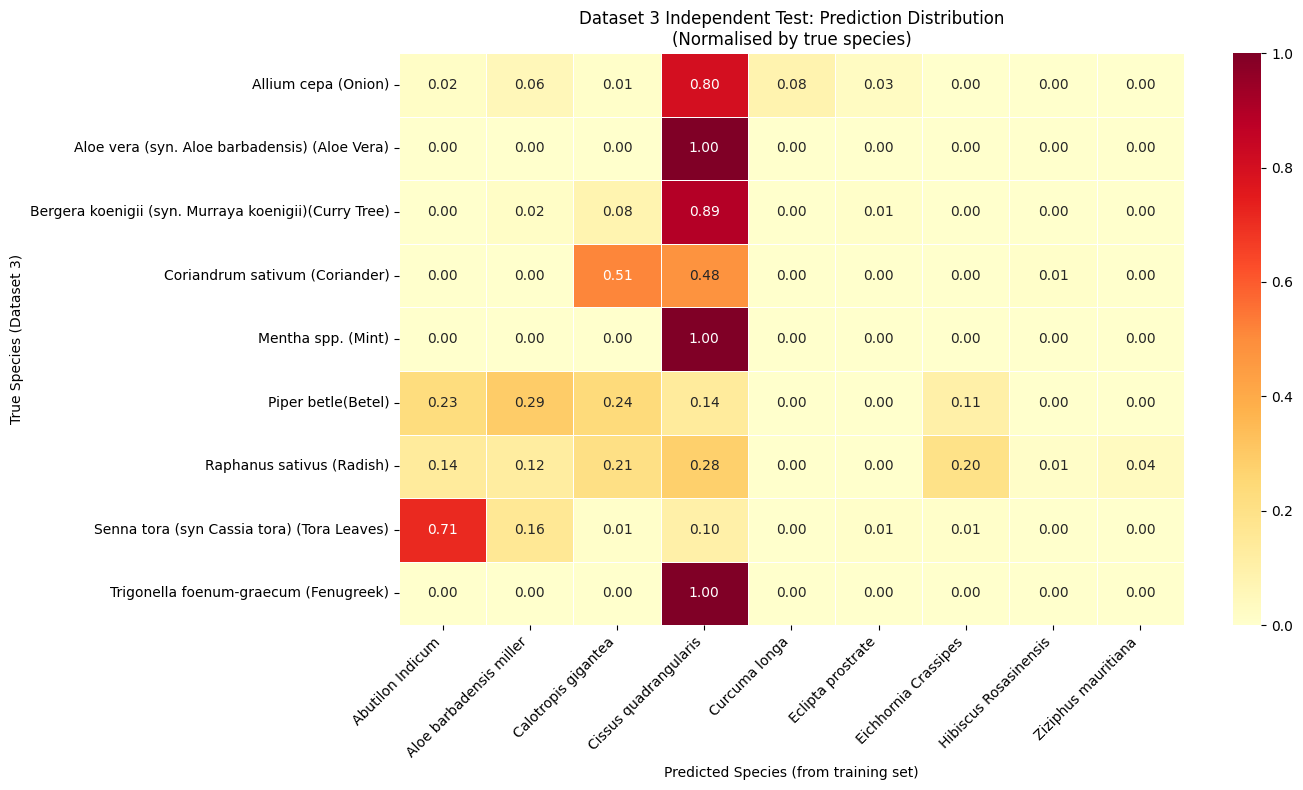

Saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/dataset3_results/dataset3_confusion_matrix.png


In [9]:
print("\n>>> Generating confusion matrix...")

# For the confusion matrix, we show what the model predicted for each D3 species
# This is an open-set recognition scenario for novel species

# Create a mapping plot showing D3 species → predicted taxa
fig, ax = plt.subplots(figsize=(14, 8))

# Build confusion-like matrix: rows = true D3 species, cols = predicted species
all_pred_species = sorted(set(pred_class_names))
matrix = np.zeros((len(d3_classes), len(all_pred_species)))

for true_label, pred_label in zip(all_true_labels, pred_class_names):
    row = d3_classes.index(true_label)
    col = all_pred_species.index(pred_label)
    matrix[row, col] += 1

# Normalise by row
row_sums = matrix.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
matrix_norm = matrix / row_sums

# Only show columns that have any predictions
col_mask = matrix.sum(axis=0) > 0
shown_cols = [c for c, m in zip(all_pred_species, col_mask) if m]
matrix_shown = matrix_norm[:, col_mask]

sns.heatmap(matrix_shown, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=shown_cols, yticklabels=d3_classes,
            ax=ax, vmin=0, vmax=1, linewidths=0.5)
ax.set_xlabel('Predicted Species (from training set)')
ax.set_ylabel('True Species (Dataset 3)')
ax.set_title('Dataset 3 Independent Test: Prediction Distribution\n(Normalised by true species)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

fig.savefig(os.path.join(RESULTS_DIR, 'dataset3_confusion_matrix.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/dataset3_confusion_matrix.png")

## Confidence Distribution Plot

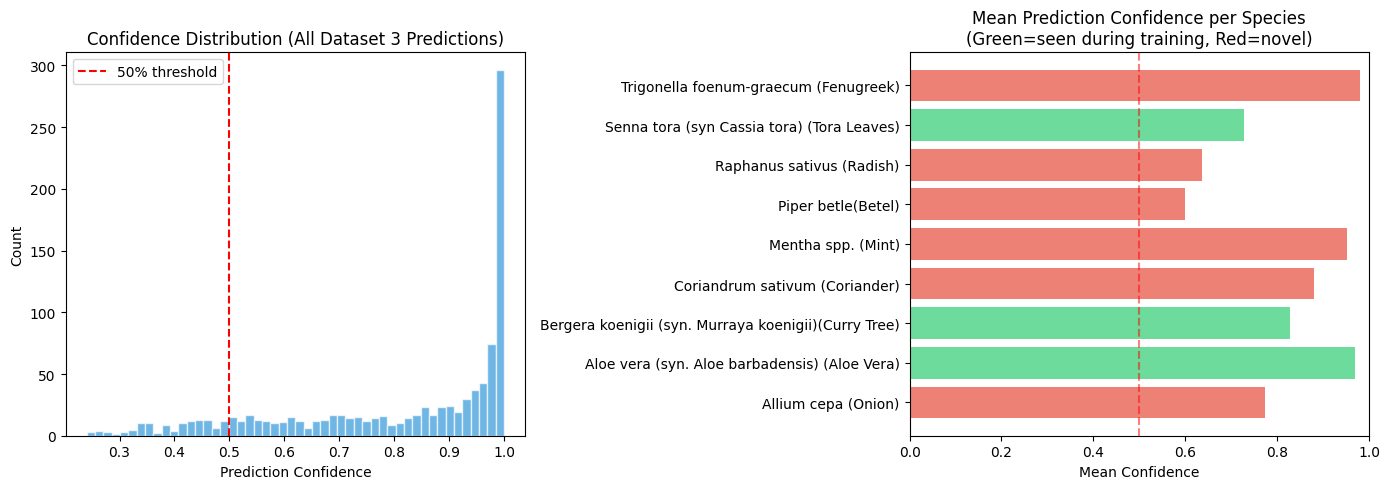

Saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/dataset3_results/dataset3_confidence.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall confidence histogram
axes[0].hist(pred_confidences, bins=50, color='#3498db', alpha=0.7, edgecolor='white')
axes[0].axvline(x=0.5, color='red', linestyle='--', label='50% threshold')
axes[0].set_xlabel('Prediction Confidence')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence Distribution (All Dataset 3 Predictions)')
axes[0].legend()

# Per-species mean confidence
species_mean_conf = []
for species in d3_classes:
    mask = [t == species for t in all_true_labels]
    confs = [pred_confidences[i] for i, m in enumerate(mask) if m]
    species_mean_conf.append(np.mean(confs))

colors = ['#2ecc71' if species.lower().strip() in overlap else '#e74c3c' for species in d3_classes]
bars = axes[1].barh(d3_classes, species_mean_conf, color=colors, alpha=0.7)
axes[1].set_xlabel('Mean Confidence')
axes[1].set_title('Mean Prediction Confidence per Species\n(Green=seen during training, Red=novel)')
axes[1].set_xlim(0, 1)
axes[1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'dataset3_confidence.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/dataset3_confidence.png")

## Grad-CAM Visualisations


>>> Generating Grad-CAM visualisations...
Generating Grad-CAM for selected images...
  Using conv layer: conv5_block3_3_conv (Conv2D)
  Using conv layer: conv5_block3_3_conv (Conv2D)
  Using conv layer: conv5_block3_3_conv (Conv2D)
  Using conv layer: conv5_block3_3_conv (Conv2D)
  Using conv layer: conv5_block3_3_conv (Conv2D)
  Using conv layer: conv5_block3_3_conv (Conv2D)
  Using conv layer: conv5_block3_3_conv (Conv2D)
  Using conv layer: conv5_block3_3_conv (Conv2D)
  Using conv layer: conv5_block3_3_conv (Conv2D)


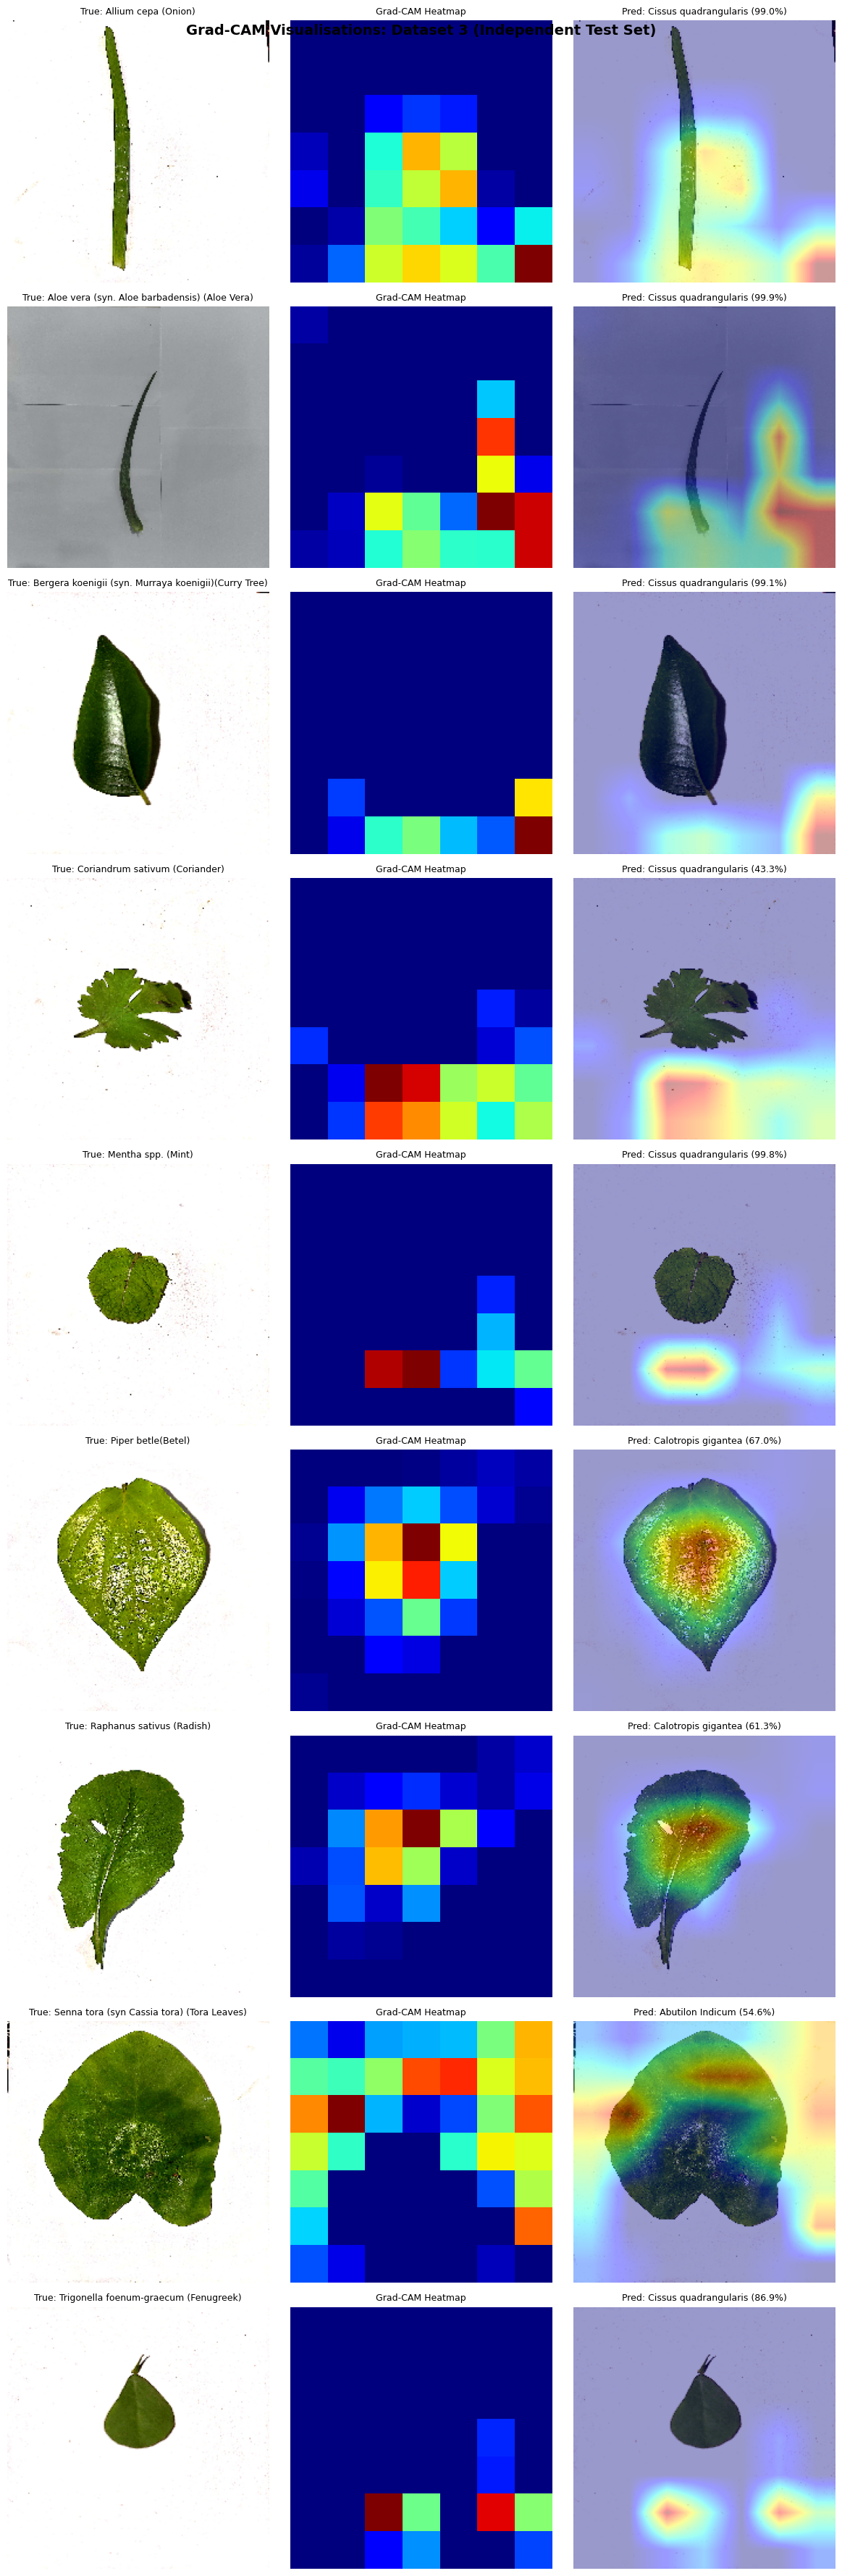

Saved: /content/drive/MyDrive/MedicinalPlant_Dissertation/dataset3_results/gradcam_dataset3.png


In [11]:
print("\n>>> Generating Grad-CAM visualisations...")

def make_gradcam_heatmap(model, img_array, pred_index=None):
    """Generate Grad-CAM heatmap (Keras 3 / TF 2.16+ compatible).

    Handles nested backbone models (ResNet50/EfficientNet) and uses
    class-name-based layer detection instead of isinstance() which
    can fail on deserialized Keras 3 models.
    """
    # ── Step 1: Find backbone and last Conv2D layer ──
    backbone = None
    backbone_idx = None

    for i, layer in enumerate(model.layers):
        if hasattr(layer, 'layers') and len(layer.layers) > 5:
            backbone = layer
            backbone_idx = i
            break

    last_conv = None
    search_layers = backbone.layers if backbone is not None else model.layers

    for layer in reversed(search_layers):
        # Use class name string check  more robust than isinstance() for loaded models
        class_name = layer.__class__.__name__
        if class_name == 'Conv2D' or 'conv2d' in class_name.lower():
            last_conv = layer
            break

    if last_conv is None:
        print(f"  WARNING: No Conv2D layer found")
        if backbone:
            layer_types = set(l.__class__.__name__ for l in backbone.layers)
            print(f"  Backbone layer types: {sorted(layer_types)}")
        return None

    print(f"  Using conv layer: {last_conv.name} ({last_conv.__class__.__name__})")

    # ── Step 2: Build gradient model ──
    if backbone is not None:
        # Build feature extractor from backbone only (avoids input_layer name clash)
        try:
            feature_model = tf.keras.Model(
                inputs=backbone.input,
                outputs=[last_conv.output, backbone.output],
            )
        except Exception as e:
            print(f"  Feature model build failed: {e}")
            return None

        img_tensor = tf.cast(img_array, tf.float32)

        with tf.GradientTape() as tape:
            conv_output, backbone_out = feature_model(img_tensor)
            tape.watch(conv_output)

            # Apply remaining layers after backbone manually
            x = backbone_out
            for li in range(backbone_idx + 1, len(model.layers)):
                x = model.layers[li](x)

            predictions = x
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, conv_output)
    else:
        # Flat model  build sub-model directly
        try:
            grad_model = tf.keras.Model(
                model.inputs, [last_conv.output, model.layers[-1].output]
            )
        except Exception as e:
            print(f"  Grad model build failed: {e}")
            return None

        img_tensor = tf.cast(img_array, tf.float32)

        with tf.GradientTape() as tape:
            conv_output, predictions = grad_model(img_tensor)
            tape.watch(conv_output)
            if pred_index is None:
                pred_index = tf.argmax(predictions[0])
            class_channel = predictions[:, pred_index]

        grads = tape.gradient(class_channel, conv_output)

    if grads is None:
        print(f"  WARNING: Gradients are None")
        return None

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_output = conv_output[0]
    heatmap = conv_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap(img, heatmap, alpha=0.4):
    """Overlay Grad-CAM heatmap on the original image."""
    import cv2
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_colored = plt.cm.jet(heatmap_resized)[:, :, :3]
    overlaid = img * (1 - alpha) + heatmap_colored * alpha
    return np.clip(overlaid, 0, 1)


# Select representative images: 1 per species
print("Generating Grad-CAM for selected images...")
fig_rows = len(d3_classes)
fig, axes = plt.subplots(fig_rows, 3, figsize=(12, 4 * fig_rows))

for row, species in enumerate(d3_classes):
    species_indices = [i for i, t in enumerate(all_true_labels) if t == species]
    if not species_indices:
        continue

    idx = species_indices[0]
    img = all_images[idx]
    img_batch = np.expand_dims(img, 0)

    pred_idx = pred_class_indices[idx]
    pred_name = pred_class_names[idx]
    pred_conf = pred_confidences[idx]

    # Original image
    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f'True: {species}', fontsize=9)
    axes[row, 0].axis('off')

    # Grad-CAM
    heatmap = make_gradcam_heatmap(model, img_batch, pred_idx)
    if heatmap is not None:
        axes[row, 1].imshow(heatmap, cmap='jet')
        axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=9)
    else:
        axes[row, 1].text(0.5, 0.5, 'N/A', ha='center', va='center')
        axes[row, 1].set_title('Grad-CAM (failed)', fontsize=9)
    axes[row, 1].axis('off')

    # Overlay
    if heatmap is not None:
        overlay = overlay_heatmap(img, heatmap)
        axes[row, 2].imshow(overlay)
    else:
        axes[row, 2].imshow(img)
    axes[row, 2].set_title(f'Pred: {pred_name} ({pred_conf:.1%})', fontsize=9)
    axes[row, 2].axis('off')

fig.suptitle('Grad-CAM Visualisations: Dataset 3 (Independent Test Set)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
fig.savefig(os.path.join(RESULTS_DIR, 'gradcam_dataset3.png'), dpi=200, bbox_inches='tight')
plt.show()
print(f"Saved: {RESULTS_DIR}/gradcam_dataset3.png")

## Save Complete Results

In [12]:
print("\n>>> Saving complete results...")

results = {
    "dataset": "Dataset 3 (Independent Test Set)",
    "total_images": len(all_images),
    "species_count": len(d3_classes),
    "species": d3_classes,
    "overlapping_species": [d3_sp for d3_sp in sorted(overlap_map.keys())] if overlap_map else [],
    "overlapping_species_mapping": {d3: train for d3, train in overlap_map.items()} if overlap_map else {},
    "novel_species": sorted(d3_only_list),
    "mean_confidence": float(np.mean(pred_confidences)),
    "median_confidence": float(np.median(pred_confidences)),
    "low_confidence_pct": float(low_conf / len(pred_confidences) * 100),
}

if overlap_total > 0:
    results["overlapping_species_accuracy"] = float(overlap_correct / overlap_total)

# Per-species breakdown
from collections import Counter
per_species = {}
for species in d3_classes:
    mask = [t == species for t in all_true_labels]
    preds = [pred_class_names[i] for i, m in enumerate(mask) if m]
    confs = [float(pred_confidences[i]) for i, m in enumerate(mask) if m]
    per_species[species] = {
        "count": sum(mask),
        "mean_confidence": float(np.mean(confs)),
        "top_prediction": Counter(preds).most_common(1)[0] if preds else None,
        "is_novel": species not in overlap_map,
    }
results["per_species"] = per_species

with open(os.path.join(RESULTS_DIR, 'dataset3_results.json'), 'w') as f:
    json.dump(results, f, indent=2)

print(f"\nAll results saved to: {RESULTS_DIR}/")
print(f"Files:")
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"  {f}")

print("\n" + "="*60)
print("EVALUATION COMPLETE")
print("="*60)
print(f"\nKey results:")
print(f"  Training model classes: {len(train_class_names)}")
print(f"  Dataset 3 species: {len(d3_classes)}")
print(f"  Overlapping species: {len(overlap_map)}")
if overlap_total > 0:
    print(f"  Overlapping species accuracy: {overlap_correct}/{overlap_total} = {overlap_correct/overlap_total*100:.2f}%")
print(f"  Mean confidence: {np.mean(pred_confidences)*100:.2f}%")
print(f"  Novel species (unseen): {len(d3_only_list)} out of {len(d3_classes)}")
print(f"  Low confidence predictions (<50%): {low_conf/len(pred_confidences)*100:.1f}%")


>>> Saving complete results...

All results saved to: /content/drive/MyDrive/MedicinalPlant_Dissertation/dataset3_results/
Files:
  _temp_weights.h5
  dataset3_confidence.png
  dataset3_confusion_matrix.png
  dataset3_results.json
  gradcam_dataset3.png

EVALUATION COMPLETE

Key results:
  Training model classes: 20
  Dataset 3 species: 9
  Overlapping species: 3
  Overlapping species accuracy: 0/323 = 0.00%
  Mean confidence: 81.05%
  Novel species (unseen): 6 out of 9
  Low confidence predictions (<50%): 12.0%
